In [1]:
import os
from glob import glob
import matplotlib.pyplot as plt

from monai.transforms import (
    LoadImaged, 
    Compose, 
    EnsureChannelFirstd, 
    CropForegroundd, 
    RandCropByPosNegLabeld, 
    Orientationd, 
    Spacingd, 
    ScaleIntensityRangePercentilesd,
    Lambdad,
    SpatialPadd,
    ResizeWithPadOrCropd
)

c:\Users\User\anaconda3\envs\monai\Lib\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [8]:
images_dir = "dummy/images"
masks_dir = "dummy/masks"

images = sorted(glob(os.path.join(images_dir, "*.nii.gz")))
masks = sorted(glob(os.path.join(masks_dir, "*_seg.nii.gz")))

pairs = list(zip(images, masks))
print(pairs[0])

('dummy/images\\1.3.6.1.4.1.9328.50.4.0001.nii.gz', 'dummy/masks\\1.3.6.1.4.1.9328.50.4.0001_seg.nii.gz')


In [23]:
# แบบไม่มี ensure channel first
def show_comparison(raw_images, raw_masks, processed_images, processed_masks, slice_idx = None):

    axial = raw_images.shape[2] // 2
    coronal = raw_images.shape[1] // 2
    sagittal = raw_images.shape[0] // 2

    fig, axes = plt.subplots(3, 4, figsize = (10, 10))

    axes[0, 0].imshow(raw_images[:, :, axial].T, cmap="gray")
    axes[0, 0].set_title("Raw Image (Axial)")

    axes[0, 1].imshow(raw_masks[:, :, axial].T)
    axes[0, 1].set_title("Raw Mask (Axial)")

    axes[0, 2].imshow(processed_images[:, :, axial].T, cmap="gray")
    axes[0, 2].set_title("Preprocessed Image (Axial)")

    axes[0, 3].imshow(processed_masks[:, :, axial].T)
    axes[0, 3].set_title("Preprocessed Mask (Axial)")

    axes[1, 0].imshow(raw_images[:, coronal, :].T, cmap="gray")
    axes[1, 0].set_title("Raw Image (Coronal)")

    axes[1, 1].imshow(raw_masks[:, coronal, :].T)
    axes[1, 1].set_title("Raw Mask (Coronal)")

    axes[1, 2].imshow(processed_images[:, coronal, :].T, cmap="gray")
    axes[1, 2].set_title("Preprocessed Image (Coronal)")

    axes[1, 3].imshow(processed_masks[:, coronal, :].T)
    axes[1, 3].set_title("Preprocessed Mask (Coronal)")

    axes[2, 0].imshow(raw_images[sagittal, :, :].T, cmap="gray")
    axes[2, 0].set_title("Raw Image (Sagittal)")

    axes[2, 1].imshow(raw_masks[sagittal, :, :].T)
    axes[2, 1].set_title("Raw Mask (Sagittal)")

    axes[2, 2].imshow(processed_images[sagittal, :, :].T, cmap="gray")
    axes[2, 2].set_title("Preprocessed Image (Sagittal)")

    axes[2, 3].imshow(processed_masks[sagittal, :, :].T)
    axes[2, 3].set_title("Preprocessed Mask (Sagittal)")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Filename:  1.3.6.1.4.1.9328.50.4.0001.nii.gz


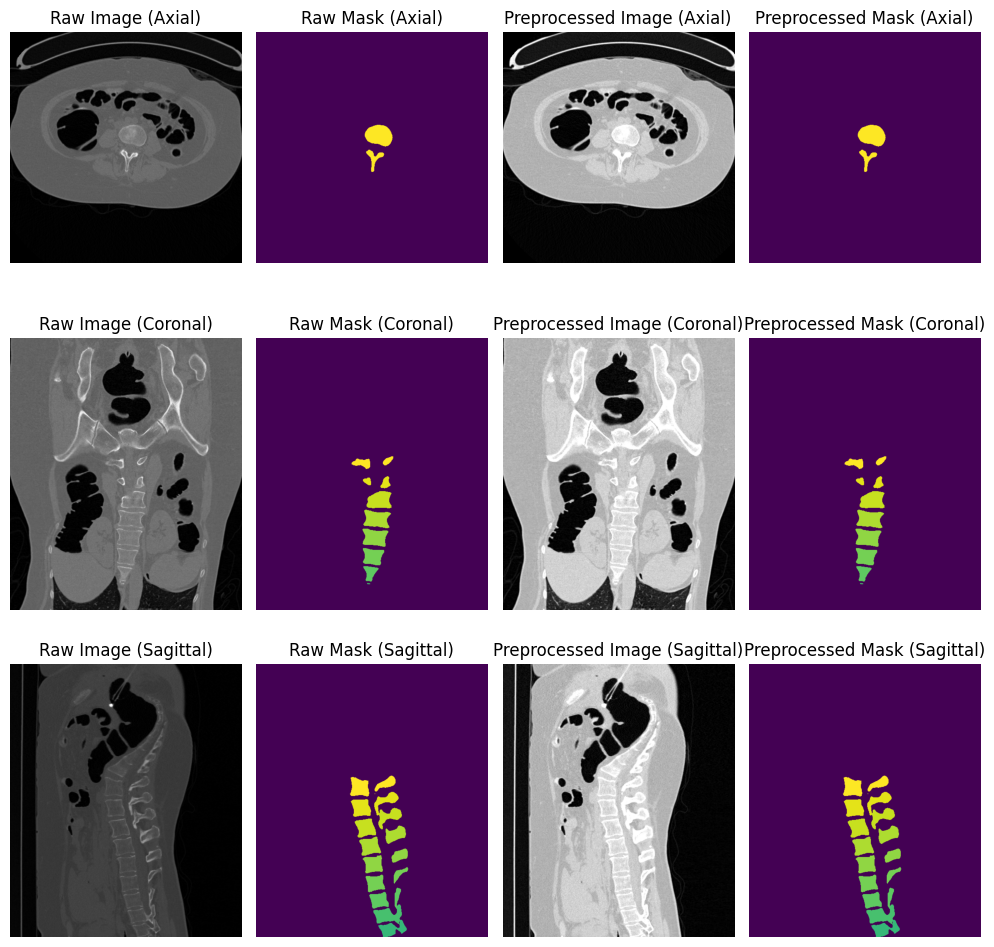

Filename:  1.3.6.1.4.1.9328.50.4.0002.nii.gz


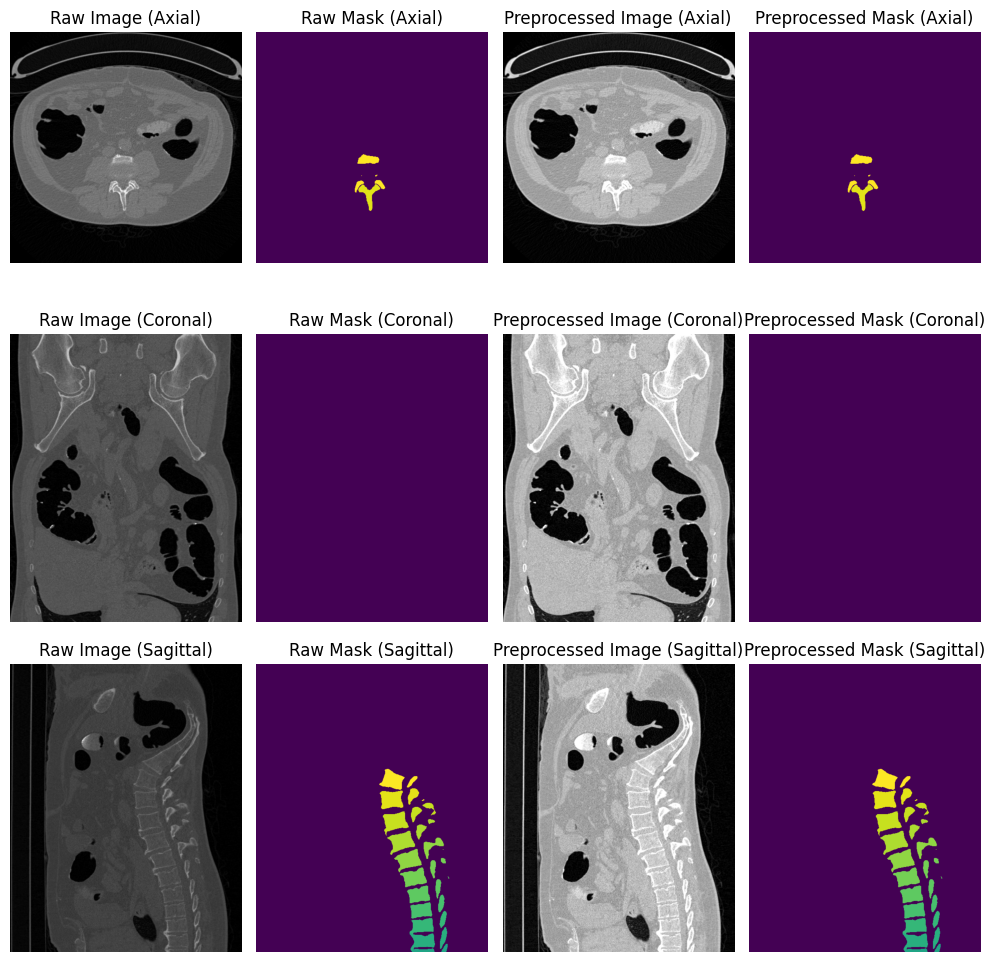

Filename:  1.3.6.1.4.1.9328.50.4.0003.nii.gz


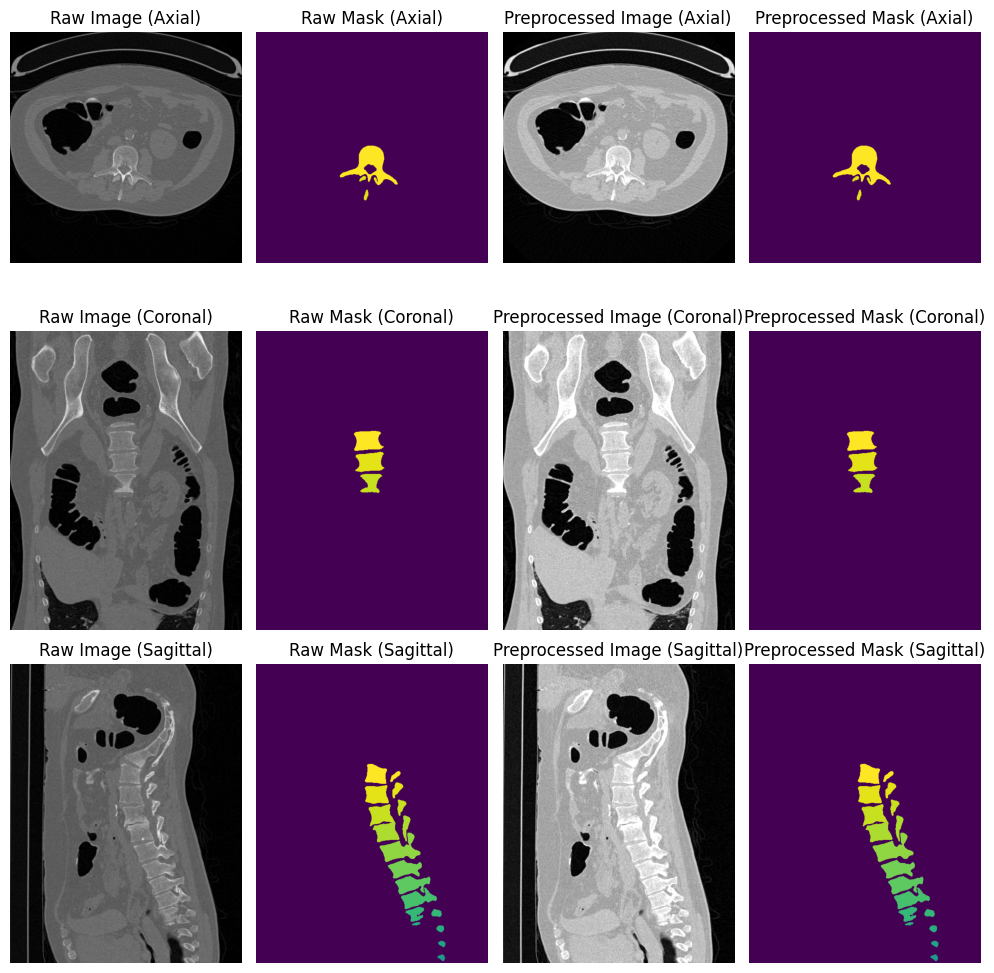

Filename:  1.3.6.1.4.1.9328.50.4.0004.nii.gz


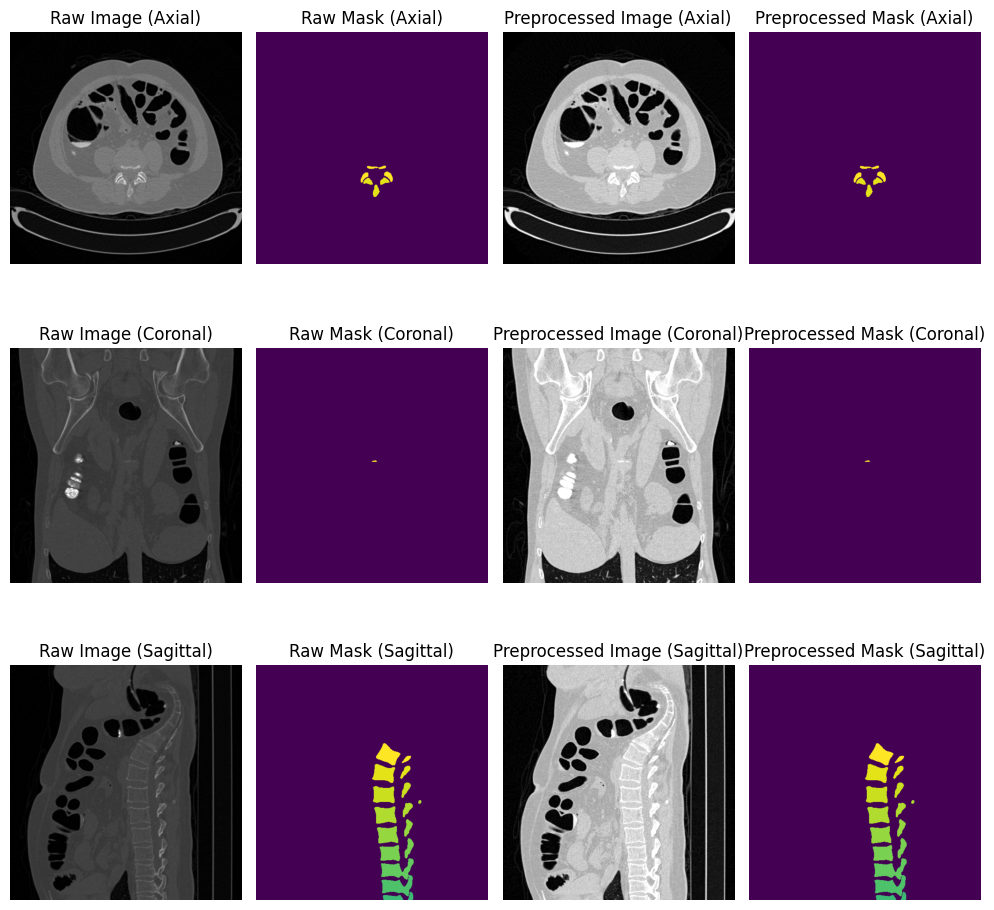

Filename:  1.3.6.1.4.1.9328.50.4.0005.nii.gz


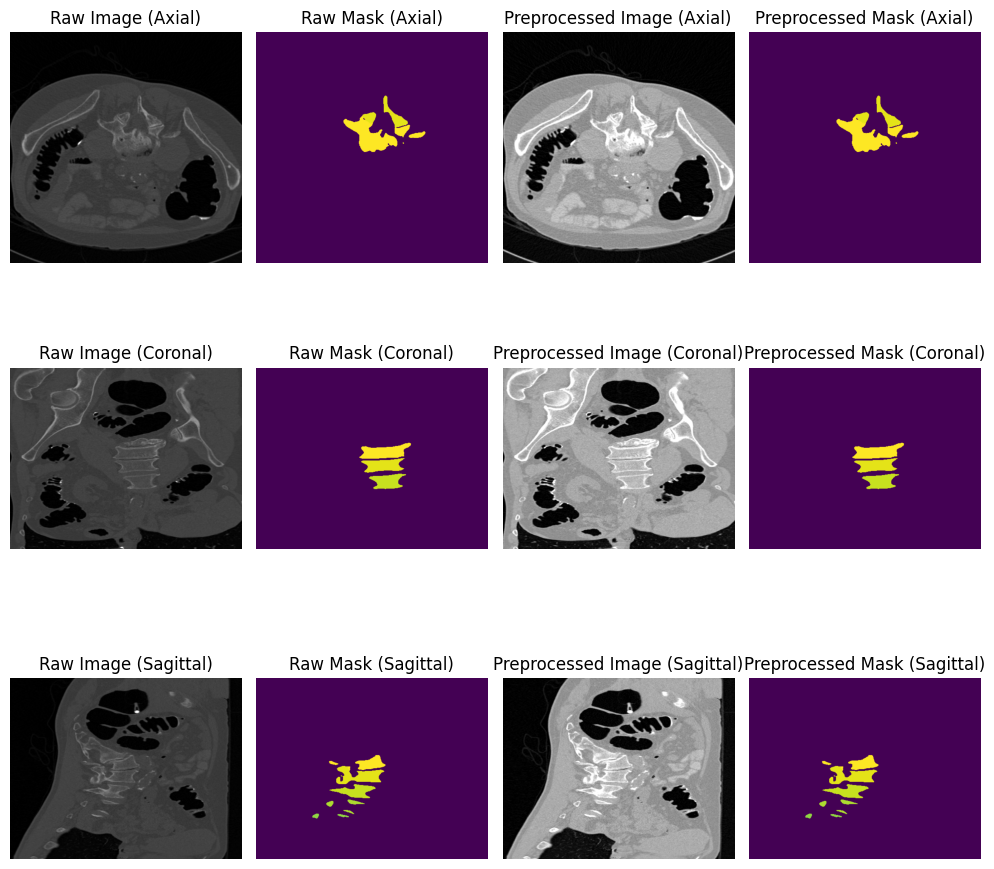

Filename:  1.3.6.1.4.1.9328.50.4.0042.nii.gz


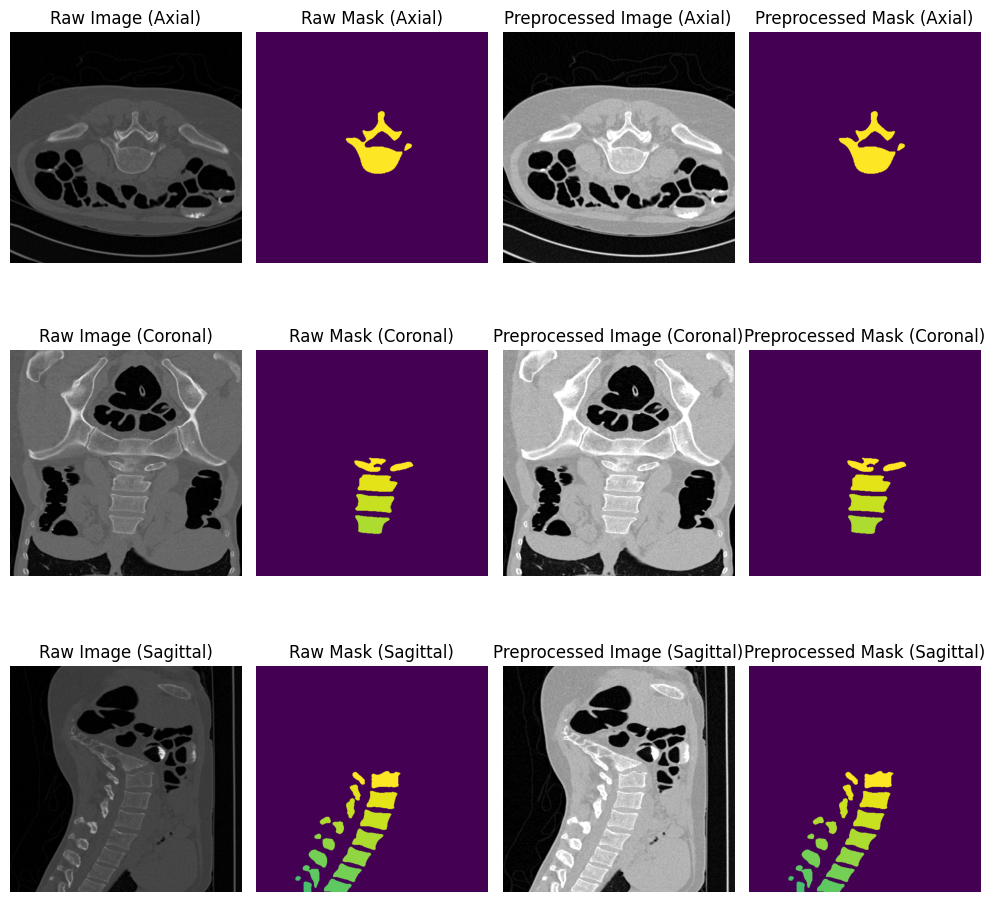

Filename:  1.3.6.1.4.1.9328.50.4.0043.nii.gz


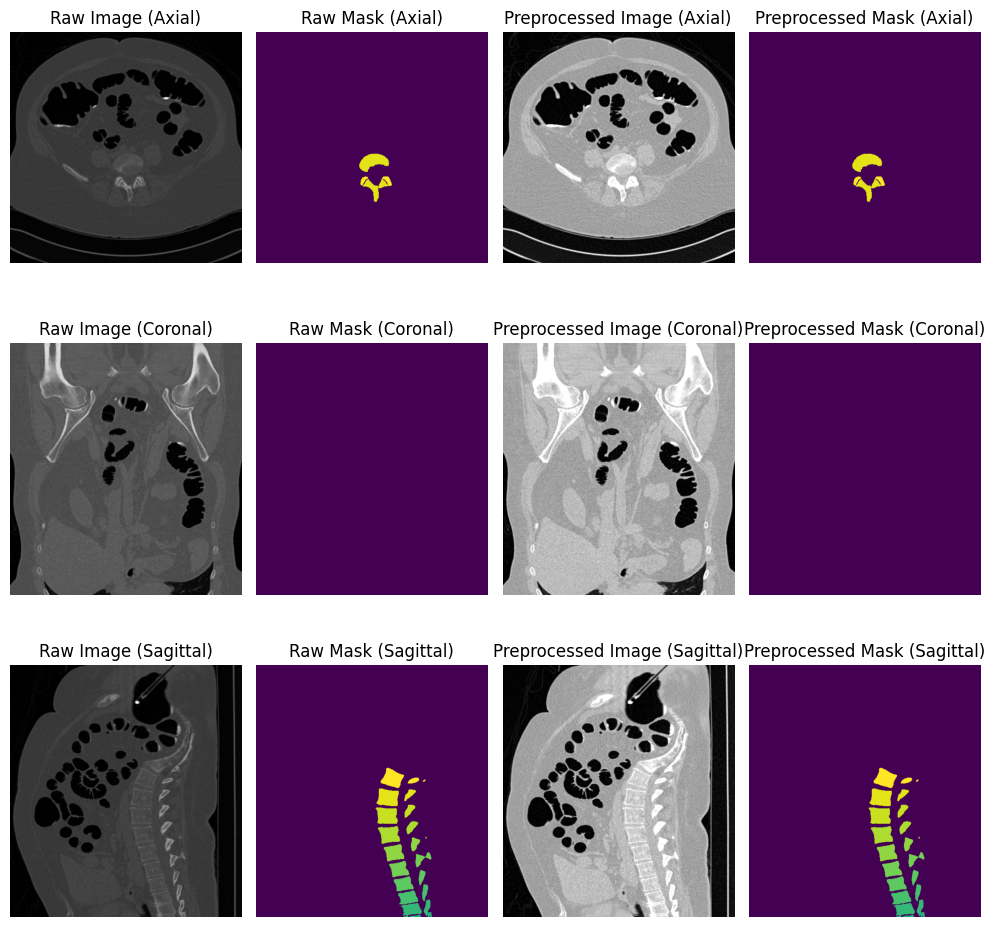

Filename:  1.3.6.1.4.1.9328.50.4.0044.nii.gz


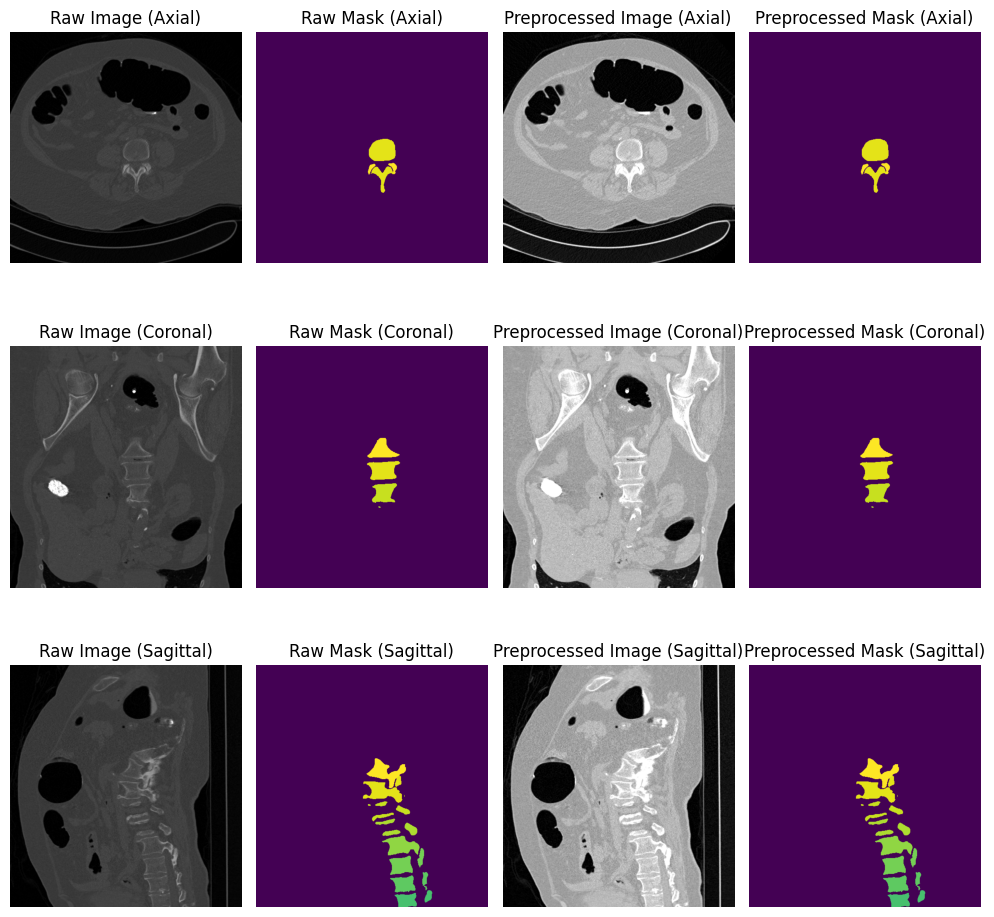

Filename:  1.3.6.1.4.1.9328.50.4.0045.nii.gz


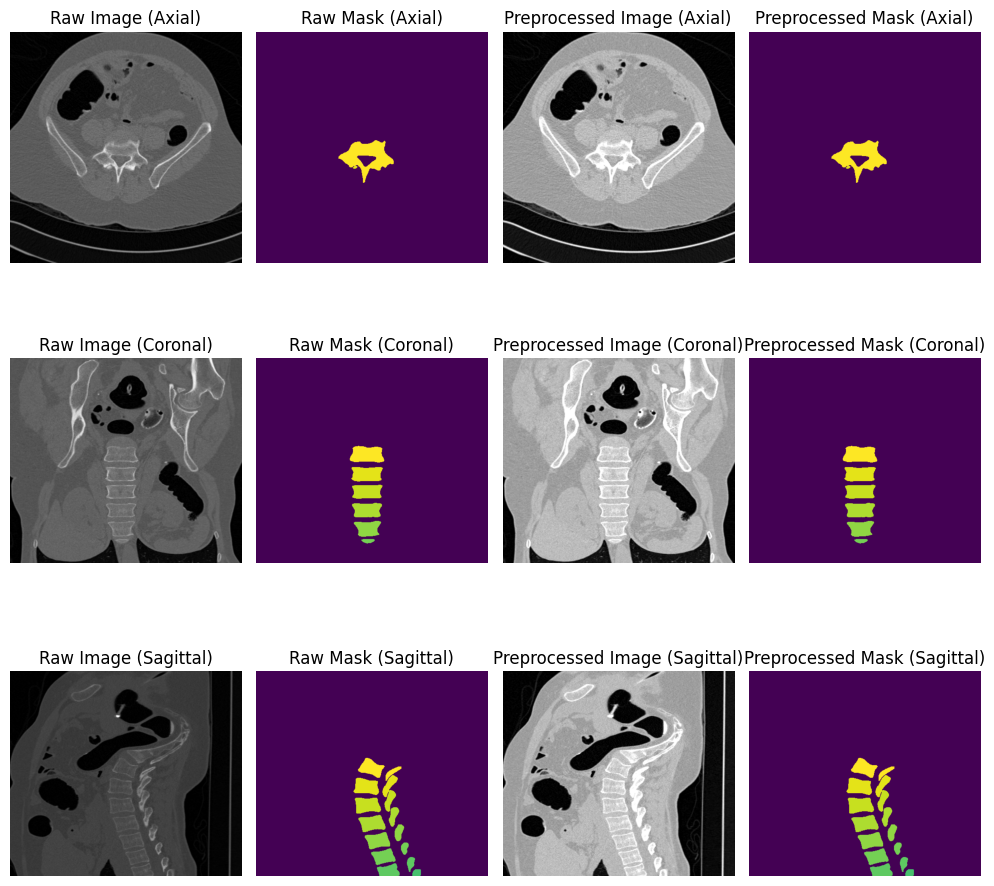

Filename:  1.3.6.1.4.1.9328.50.4.0047.nii.gz


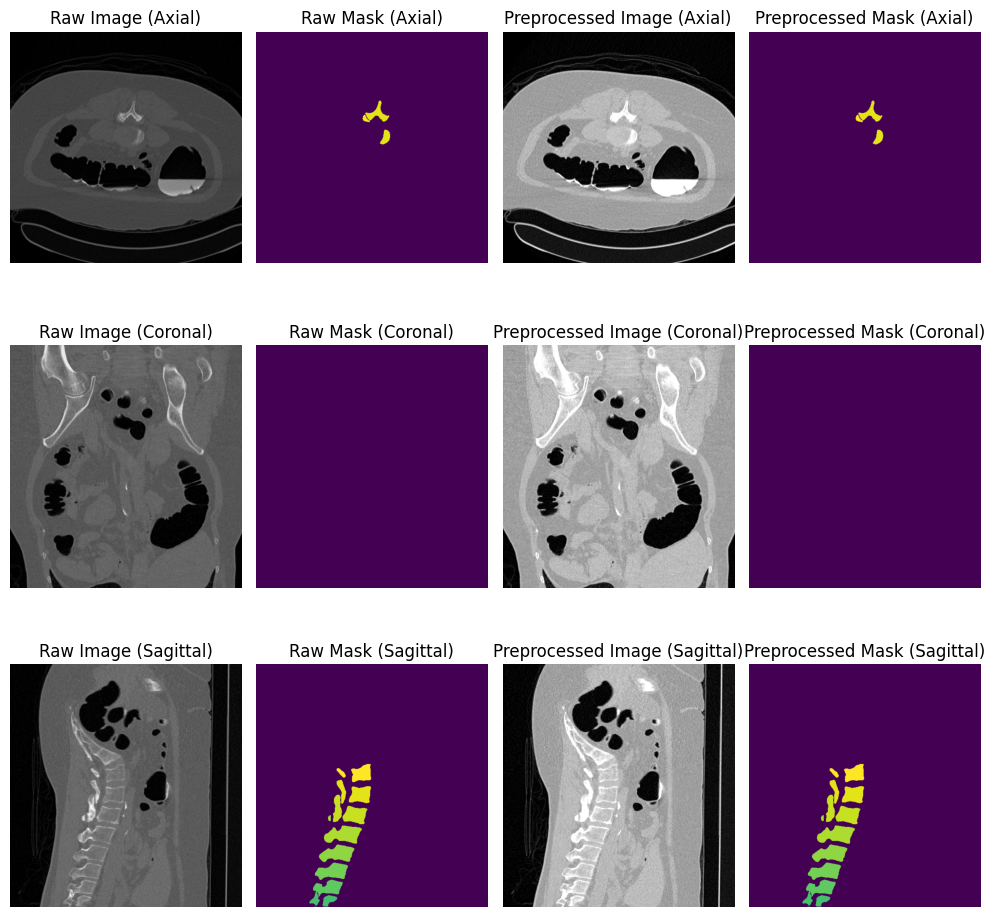

In [24]:
# ไม่ใช้ ensure channel first
loader = Compose([
    LoadImaged(keys = ["image", "mask"], image_only = False),
])

preprocess = Compose([
    LoadImaged(keys = ["image", "mask"], image_only = False),
    ScaleIntensityRangePercentilesd(keys = ["image"],
                                        lower = 5,
                                        upper = 99,
                                        b_min = 0,
                                        b_max = 1,
                                        clip = True
        )
])

for images_path, masks_path in pairs:
    raw = loader({"image": images_path, "mask": masks_path})
    preprocessd = preprocess({"image": images_path, "mask": masks_path})

    filename = os.path.basename(images_path)
    print("Filename: ", filename)

    show_comparison(raw["image"], raw["mask"], preprocessd["image"], preprocessd["mask"])

In [20]:
# แบบมี ensure channel first
def show_comparison(raw_images, raw_masks, processed_images, processed_masks, slice_idx = None):

    axial = raw_images.shape[2] // 2
    coronal = raw_images.shape[1] // 2
    sagittal = raw_images.shape[0] // 2

    fig, axes = plt.subplots(3, 4, figsize = (10, 10))

    axes[0, 0].imshow(raw_images[0, :, :, axial].T, cmap="gray")
    axes[0, 0].set_title("Raw Image (Axial)")

    axes[0, 1].imshow(raw_masks[0, :, :, axial].T)
    axes[0, 1].set_title("Raw Mask (Axial)")

    axes[0, 2].imshow(processed_images[0, :, :, axial].T, cmap="gray")
    axes[0, 2].set_title("Preprocessed Image (Axial)")

    axes[0, 3].imshow(processed_masks[0, :, :, axial].T)
    axes[0, 3].set_title("Preprocessed Mask (Axial)")

    axes[1, 0].imshow(raw_images[0, :, coronal, :].T, cmap="gray")
    axes[1, 0].set_title("Raw Image (Coronal)")

    axes[1, 1].imshow(raw_masks[0, :, coronal, :].T)
    axes[1, 1].set_title("Raw Mask (Coronal)")

    axes[1, 2].imshow(processed_images[0, :, coronal, :].T, cmap="gray")
    axes[1, 2].set_title("Preprocessed Image (Coronal)")

    axes[1, 3].imshow(processed_masks[0, :, coronal, :].T)
    axes[1, 3].set_title("Preprocessed Mask (Coronal)")

    axes[2, 0].imshow(raw_images[0, sagittal, :, :].T, cmap="gray")
    axes[2, 0].set_title("Raw Image (Sagittal)")

    axes[2, 1].imshow(raw_masks[0, sagittal, :, :].T)
    axes[2, 1].set_title("Raw Mask (Sagittal)")

    axes[2, 2].imshow(processed_images[0, sagittal, :, :].T, cmap="gray")
    axes[2, 2].set_title("Preprocessed Image (Sagittal)")

    axes[2, 3].imshow(processed_masks[0, sagittal, :, :].T)
    axes[2, 3].set_title("Preprocessed Mask (Sagittal)")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Filename:  1.3.6.1.4.1.9328.50.4.0001.nii.gz


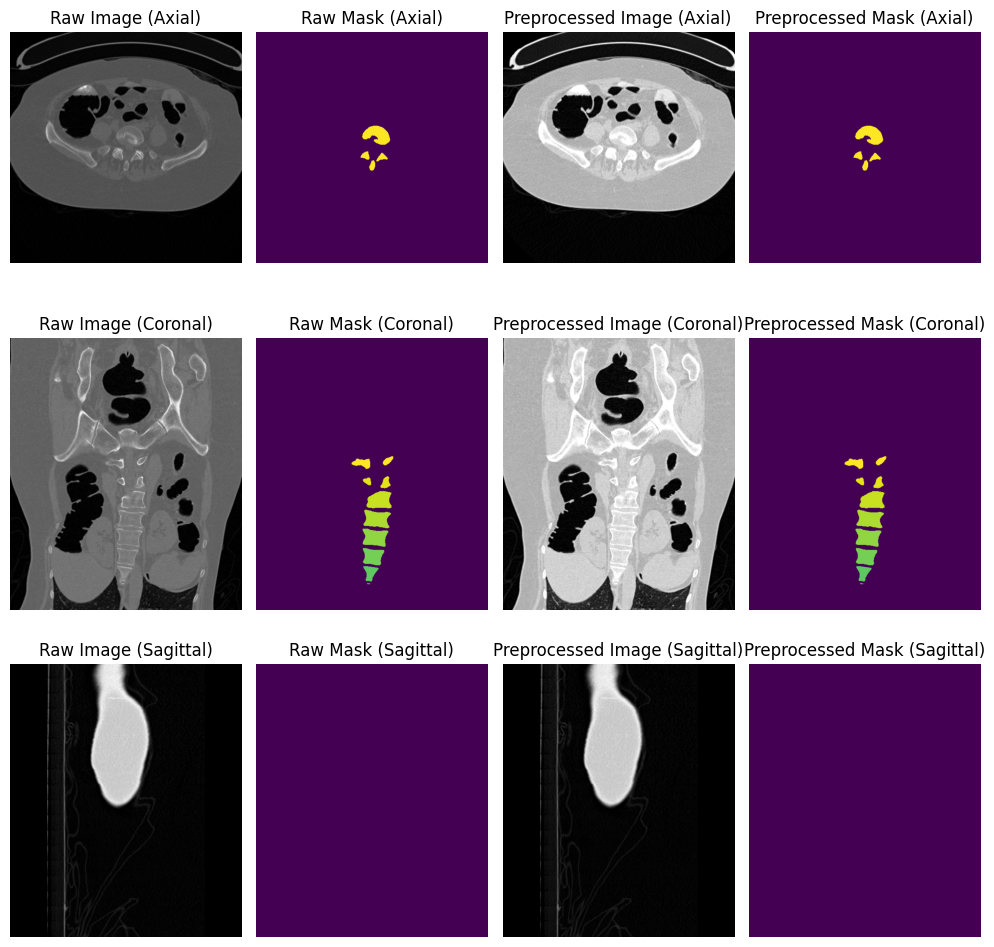

Filename:  1.3.6.1.4.1.9328.50.4.0002.nii.gz


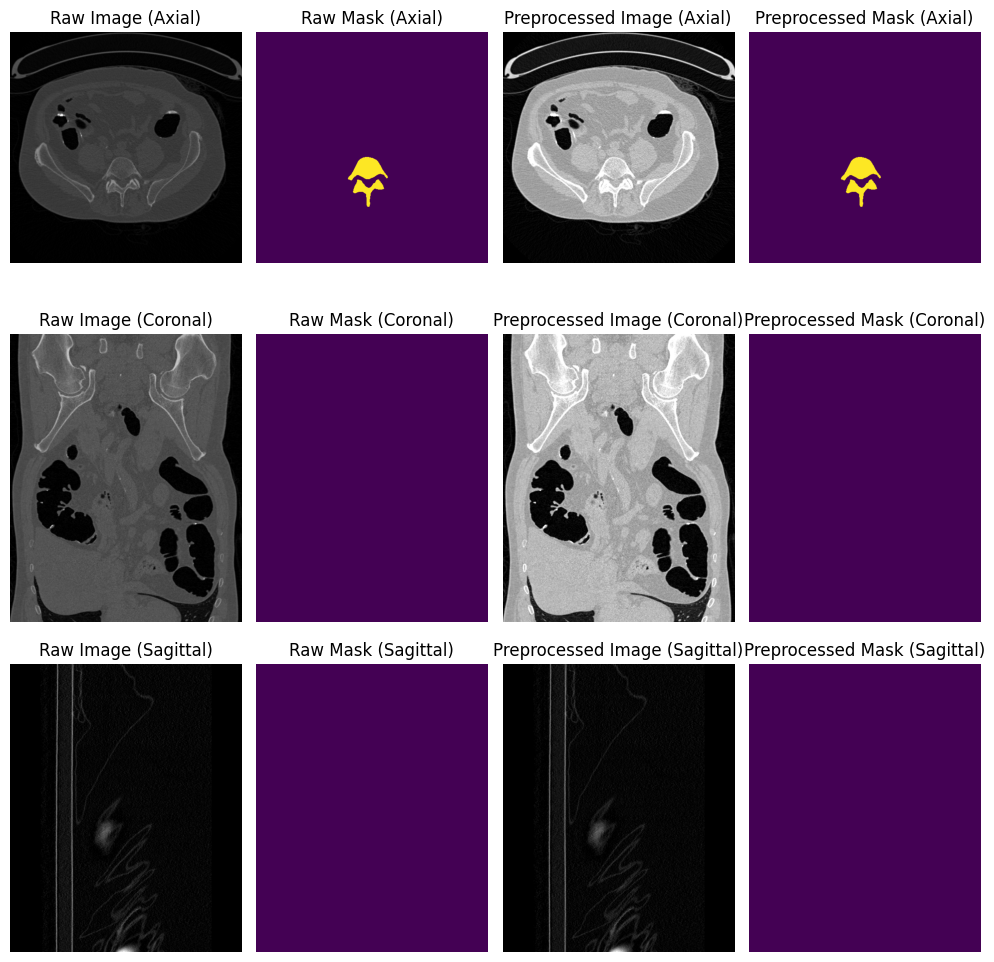

Filename:  1.3.6.1.4.1.9328.50.4.0003.nii.gz


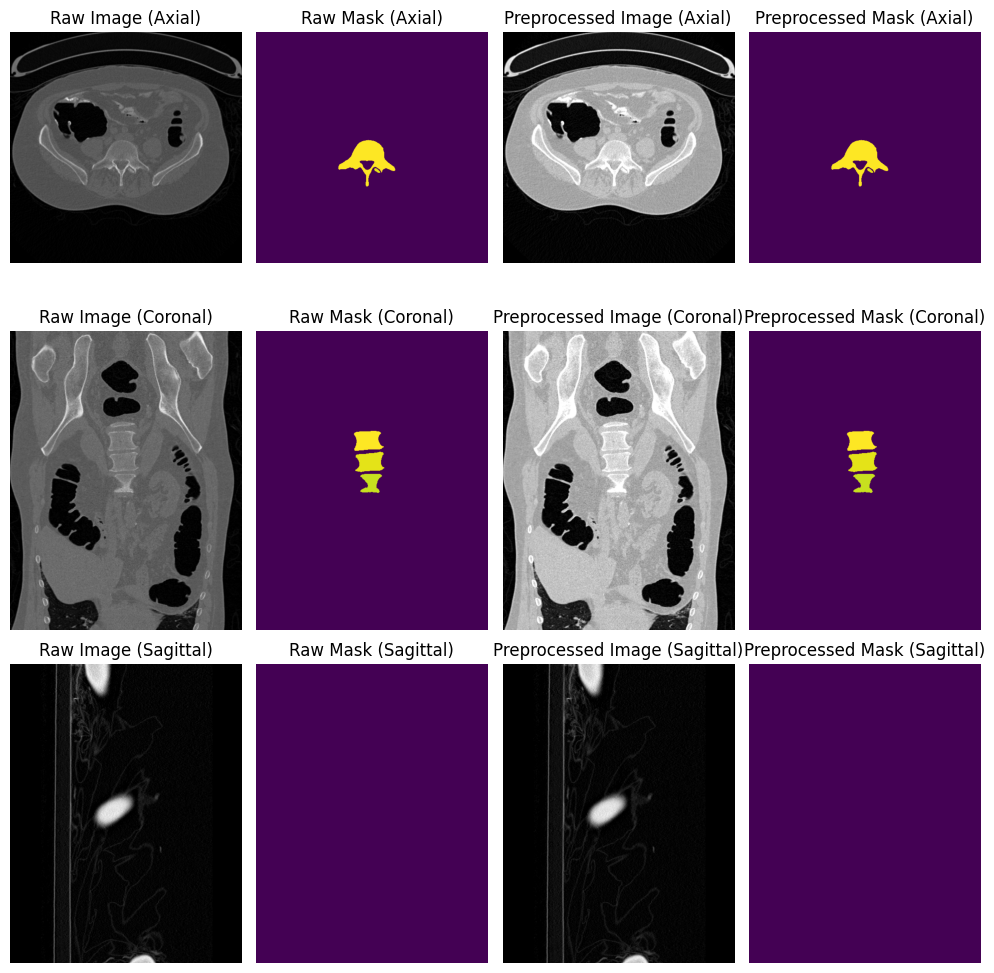

Filename:  1.3.6.1.4.1.9328.50.4.0004.nii.gz


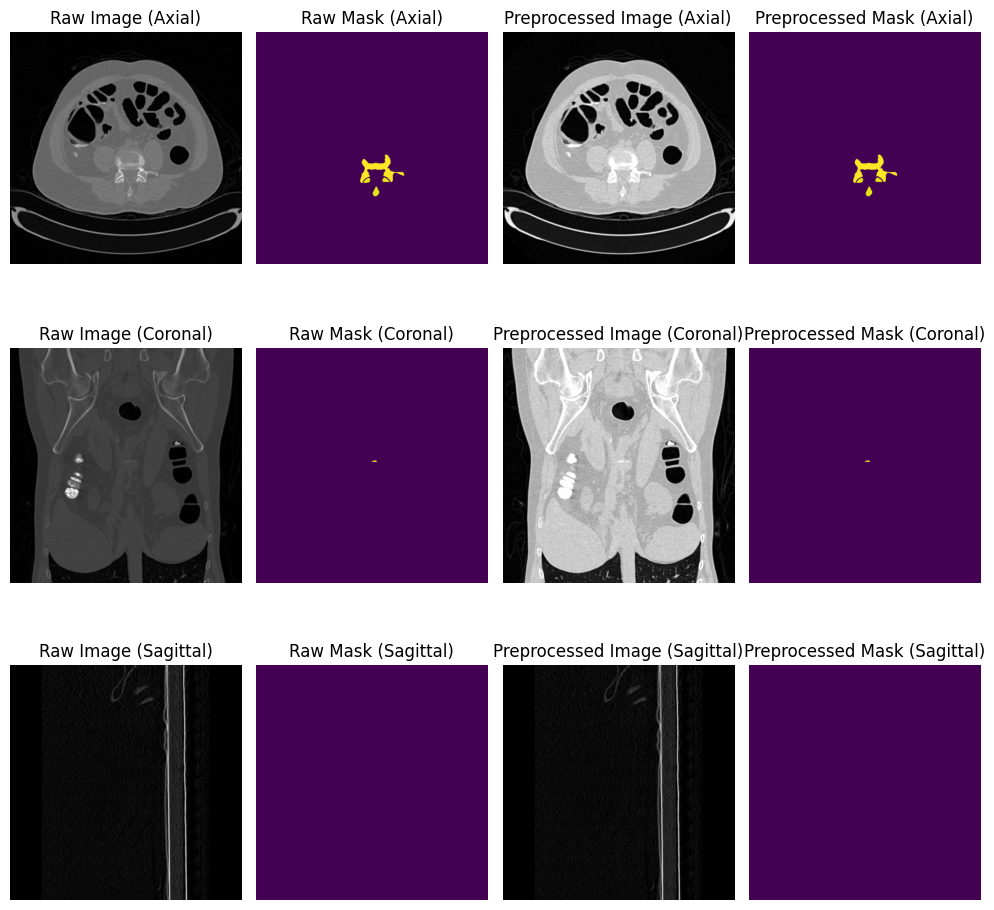

Filename:  1.3.6.1.4.1.9328.50.4.0005.nii.gz


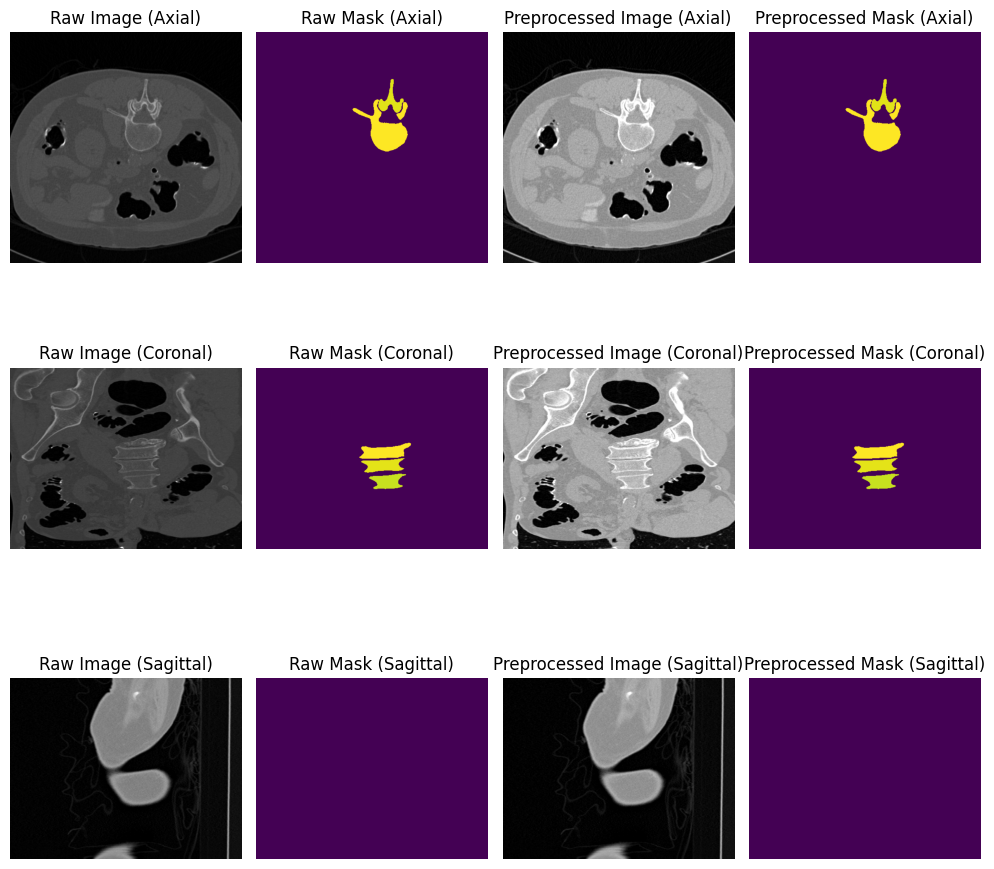

Filename:  1.3.6.1.4.1.9328.50.4.0042.nii.gz


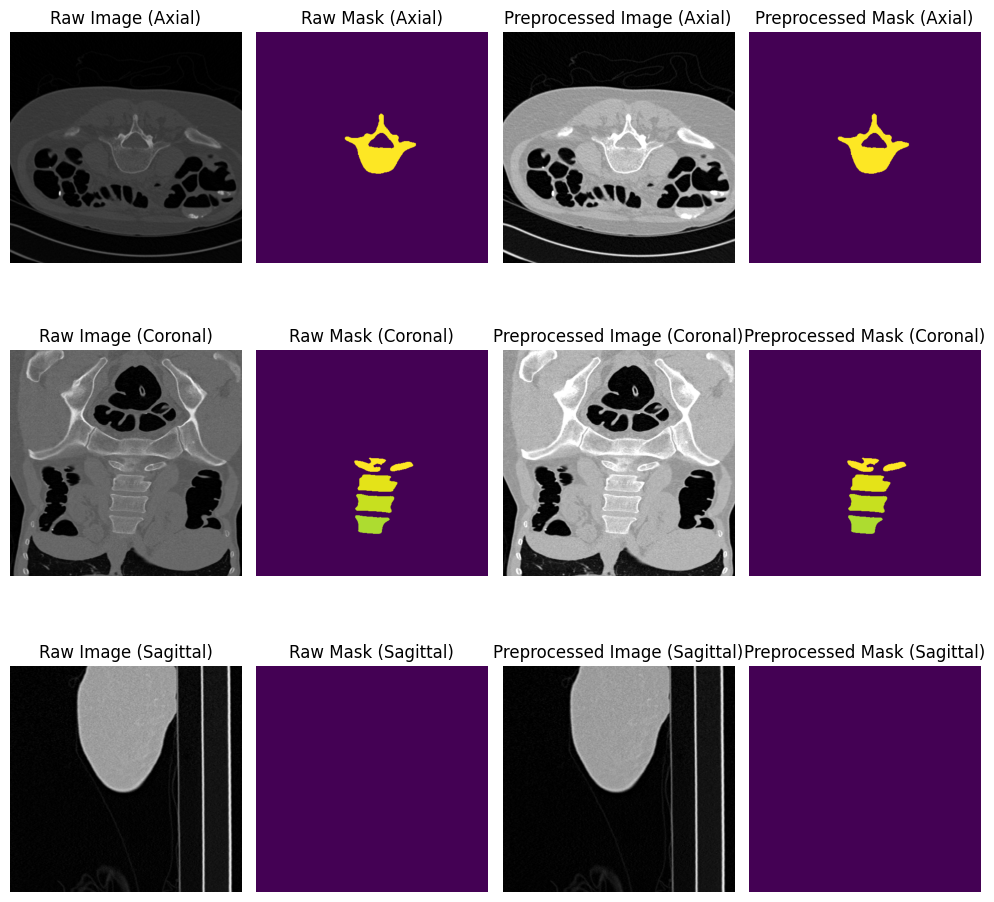

Filename:  1.3.6.1.4.1.9328.50.4.0043.nii.gz


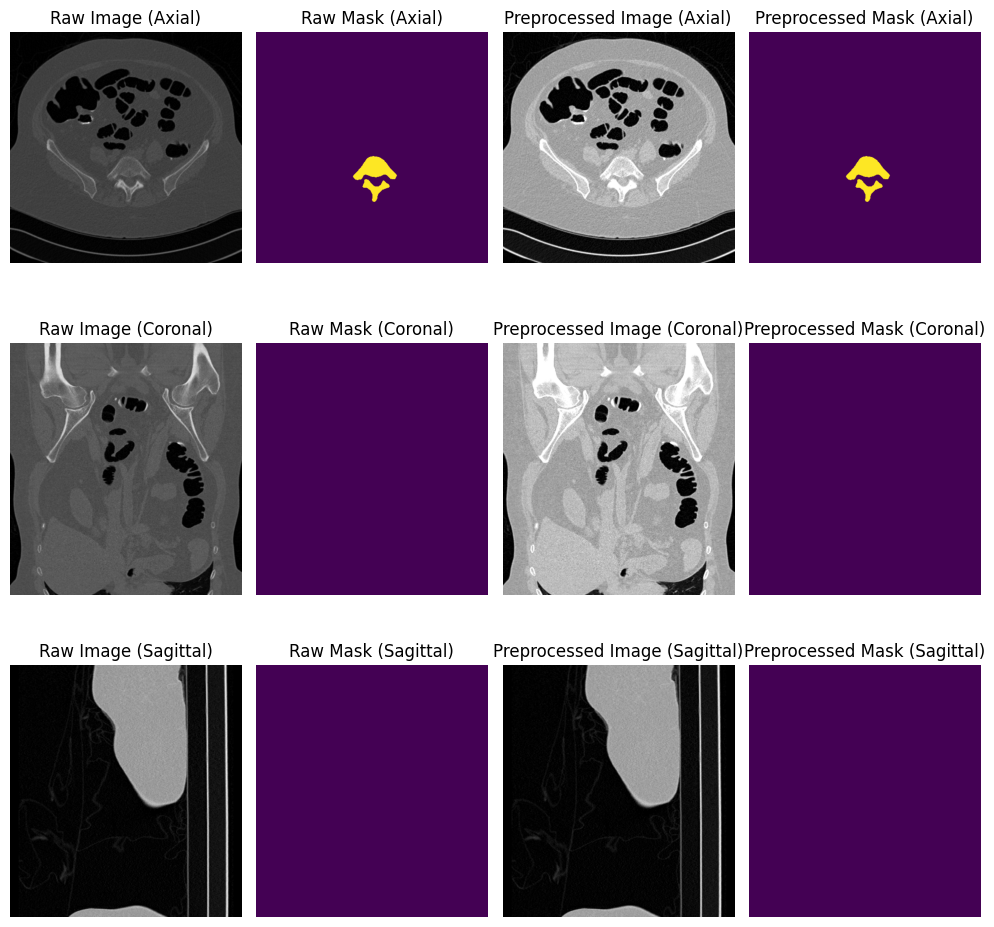

Filename:  1.3.6.1.4.1.9328.50.4.0044.nii.gz


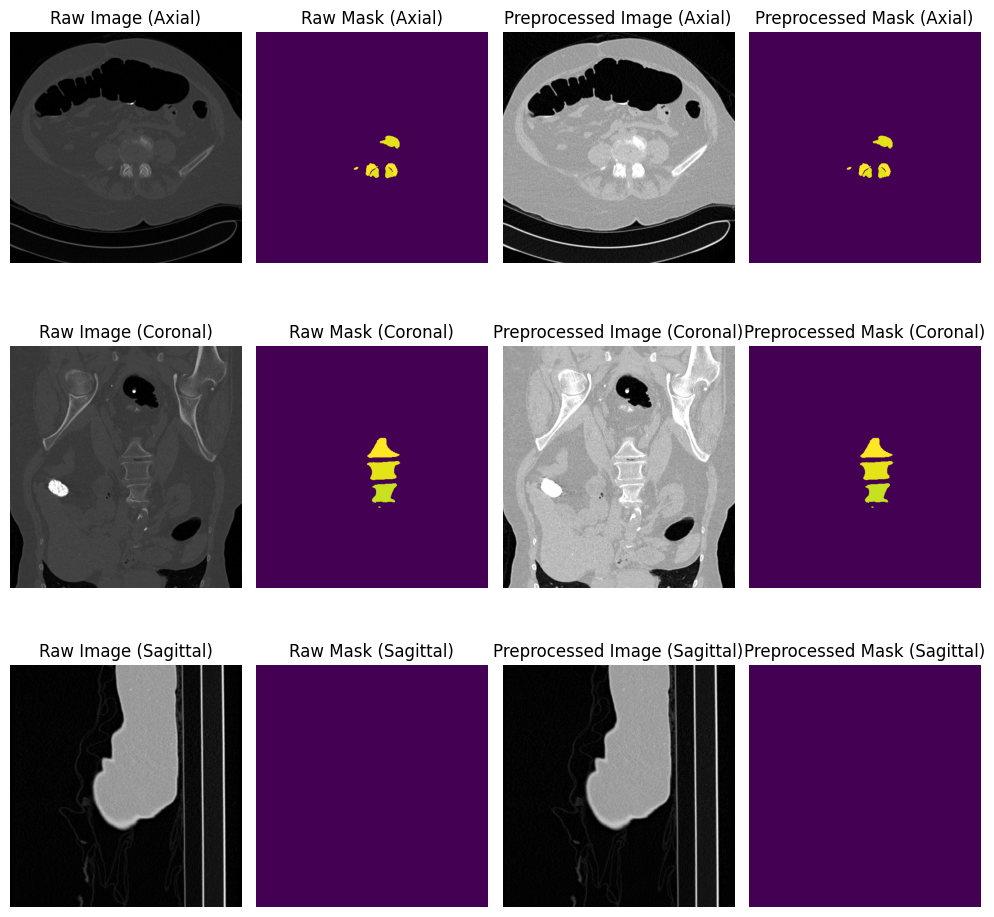

Filename:  1.3.6.1.4.1.9328.50.4.0045.nii.gz


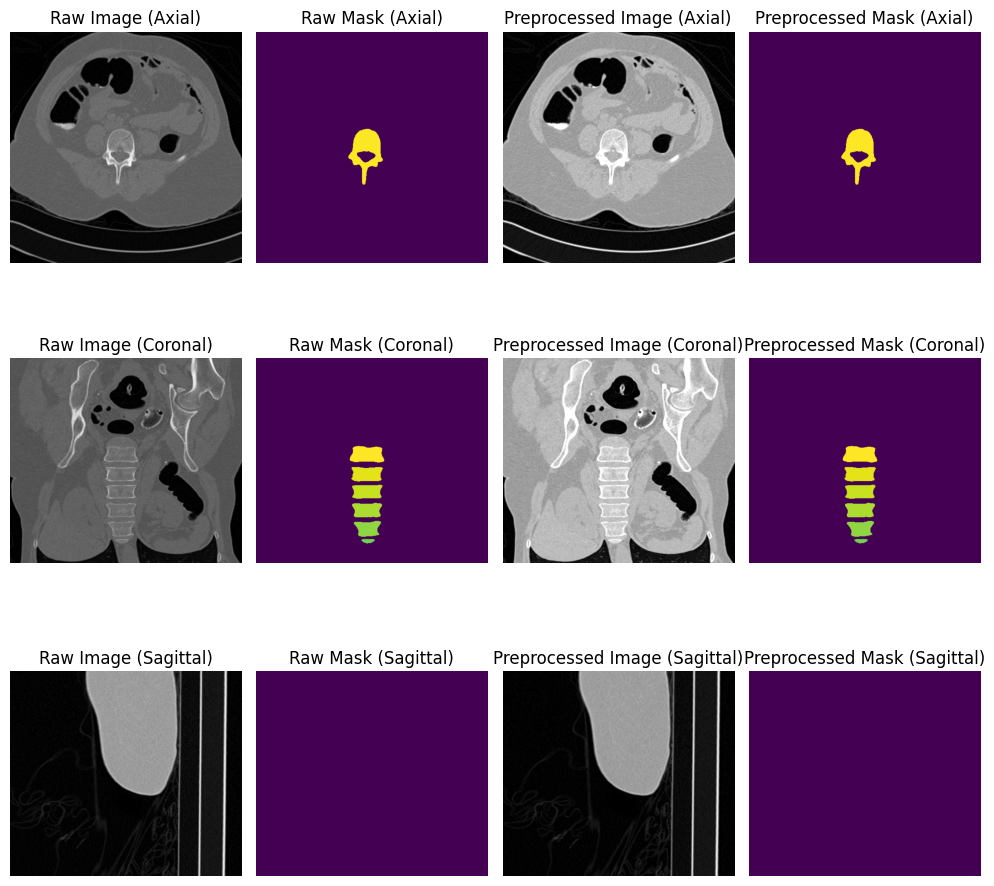

Filename:  1.3.6.1.4.1.9328.50.4.0047.nii.gz


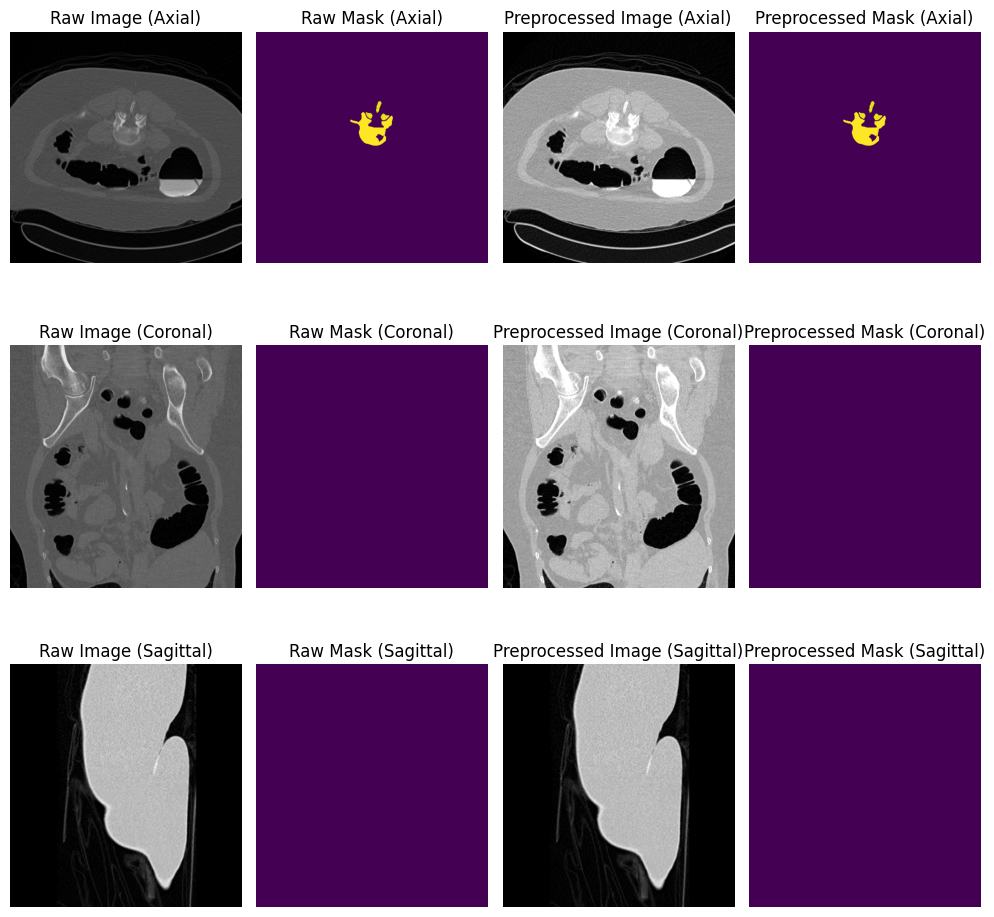

In [22]:
# ใช้ ensure channel first
loader = Compose([
    LoadImaged(keys = ["image", "mask"], image_only = False),
    EnsureChannelFirstd(keys = ["image", "mask"])
])

preprocess = Compose([
    LoadImaged(keys = ["image", "mask"], image_only = False),
    EnsureChannelFirstd(keys = ["image", "mask"]),
    ScaleIntensityRangePercentilesd(keys = ["image"],
                                        lower = 5,
                                        upper = 99,
                                        b_min = 0,
                                        b_max = 1,
                                        clip = True
        )
])

for images_path, masks_path in pairs:
    raw = loader({"image": images_path, "mask": masks_path})
    preprocessd = preprocess({"image": images_path, "mask": masks_path})

    filename = os.path.basename(images_path)
    print("Filename: ", filename)

    show_comparison(raw["image"], raw["mask"], preprocessd["image"], preprocessd["mask"])